# 1o Lab de PSD (notebook para preencher com os resultados)

### Número do Grupo : 5

In [ ]:
!pip install scikit-dsp-comm

import sk_dsp_comm.sigsys as ss
import numpy as np
import matplotlib.pyplot as plt
from sk_dsp_comm.sigsys import drect, dstep
import sk_dsp_comm.sigsys as ssd

# PROBLEMA 1
Usando as funções stem() e subplot() em python (https://matplotlib.org/stable), escreva um programa que plote os seguintes sinais
$$
\begin{align}
    x_1[n] &= \sin\big(\frac{\pi}{5}n\big),\ 0\leq n \leq 15 \\
    x_2[n] &= \cos\big(\frac{3\pi}{5}n\big),\ 0\leq n \leq 15 \\
\end{align}
$$

**OBS:** Não esqueça de incluir os títulos dos eixos.

Intervalo: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
x1 = [0.0, 0.58779, 0.95106, 0.95106, 0.58779, 0.0, -0.58779, -0.95106, -0.95106, -0.58779, -0.0, 0.58779, 0.95106, 0.95106, 0.58779, 0.0]
x2 = [1.0, -0.30901699437494734, -0.8090169943749476, 0.8090169943749473, 0.30901699437494773, -1.0, 0.309016994374947, 0.8090169943749477, -0.8090169943749471, -0.30901699437494806, 1.0, -0.3090169943749467, -0.8090169943749479, 0.8090169943749469, 0.3090169943749484, -1.0]


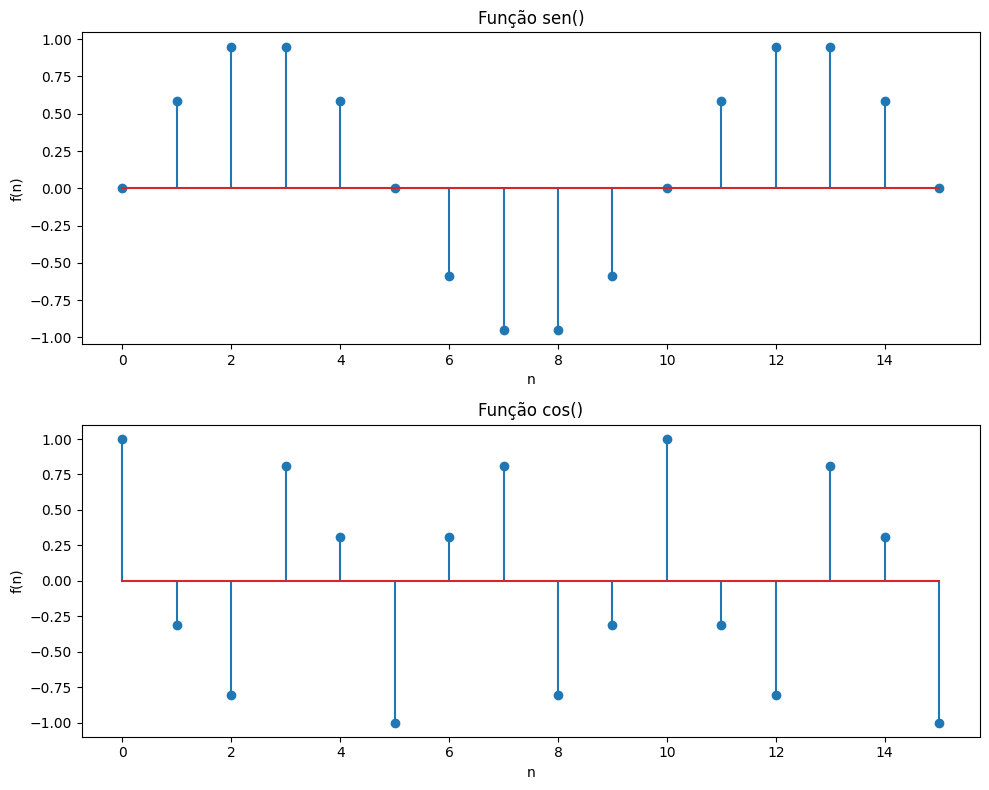

In [ ]:
# escreva o seu código aqui
np.set_printoptions(legacy='1.25')

n=16
array = np.arange(n)
print(f'Intervalo: {array}')
x1 = []
x2 = []

for i in array:
  aux = np.sin((np.pi / 5) * i)
  x1.append(round(aux, 5))

  aux2 = np.cos(((np.pi * 3) / 5) * i)
  x2.append(aux2)

print(f'x1 = {x1}')
print(f'x2 = {x2}')

fig = plt.figure( figsize=(10,8) )

sub0 = fig.add_subplot(211)
sub0.set_title('Função sen()')
sub0.stem(array, x1)
plt.xlabel("n")
plt.ylabel("f(n)")

sub1 = fig.add_subplot(212)
sub1.set_title('Função cos()')
sub1.stem(array, x2)

plt.xlabel("n")
plt.ylabel("f(n)")
fig.tight_layout()
plt.show()

## Parte a - sinal $x_1[n]$
Usando a equação vista em aula, calcule o período da fundamental, $N$, e indique no espaço abaixo. Analise o gráfico para se certificar da sua resposta.


Período: 5
Plotando o gráfico:


<StemContainer object of 3 artists>

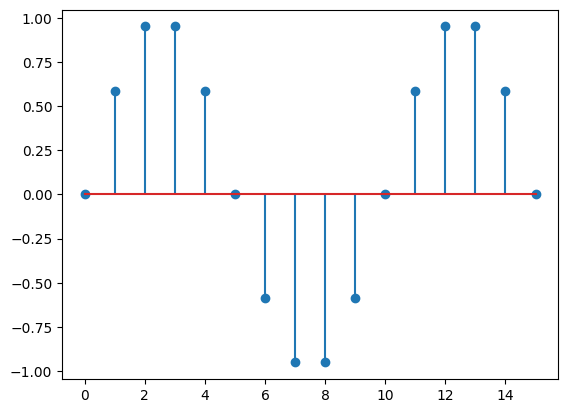

In [ ]:
# resultado e explicação aqui
x = x1.index(-x1[0], 1)
print(f'Período: {x}')

print("Plotando o gráfico:")
plt.stem(array, x1)

## Parte b - sinal $x_2[n]$
Usando a equação vista em aula, calcule o período da fundamental, $N$, e indique no espaço abaixo. Analise o gráfico para se certificar da sua resposta.


Período: 10


<StemContainer object of 3 artists>

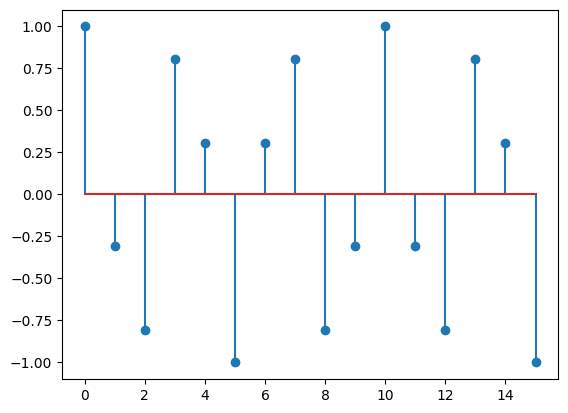

In [ ]:
# resultado e explicação aqui
x = x2.index(x2[0], 1)
print(f'Período: {x}')

plt.stem(array, x2)

# PROBLEMA 2
Usando a função `stem()` escreva um programa que plote o sinal
$$
x[n] = \begin{cases}
        2n+1, & -3\leq n\leq 3 \\
        0, & \text{otherwise}
        \end{cases}
$$
no intervalo $-8\leq n\leq 8$.

**OBS:** Criar a função $x[n]$ **sem o uso de loop!!** Observe ainda que o módulo python “sk_dsp_comm.sigsys” possui a função drect() que serve para criar uma função janela - estude o exemplo python ex2.py fornecido na aba “Material para realização dos exercícios”.

**OBS:** Não esqueça de incluir os títulos dos eixos.

Intervalo: [-8 -7 -6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8]
Valores: [-0. -0. -0. -0. -0. -5. -3. -1.  1.  3.  5.  7.  0.  0.  0.  0.  0.]


Text(0, 0.5, 'f(n)')

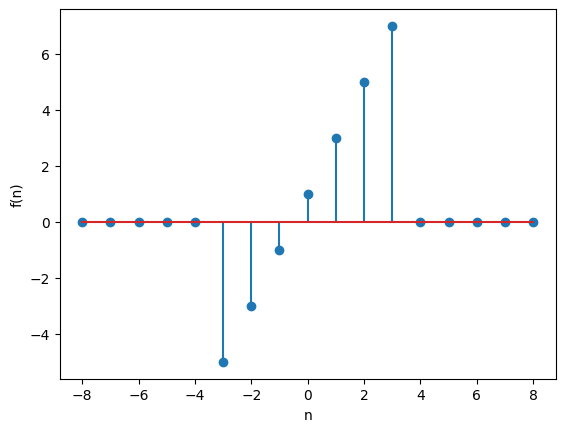

In [ ]:
# escreva o seu código aqui

m = np.arange(-8, 8+1)
y1 = 2*m + 1
y2 = drect(m+3, N=7)
y2 = y1 * y2

print(f'Intervalo: {m}')
print(f'Valores: {y2}')

plt.stem(m, y2)
plt.xlabel("n")
plt.ylabel("f(n)")

# PROBLEMA 3
Usando a função `stem()` escreva um programa que plote o sinal
$$
    x[n] = u[n]u[8-n] + u[n-2]-u[n-5]
$$
no intervalo $-2\leq n\leq 16$.  Observe que o módulo  `sk_dsp_comm.sigsys`  (aliased  como  `ss`)  possui a função `dstep()` definida, a qual pode tornar esse problema bastante simples.

**OBS:** Estude os exemplos ex1.py e ex2.py fornecidos na aba “Material para realização dos exercícios”.

<StemContainer object of 3 artists>

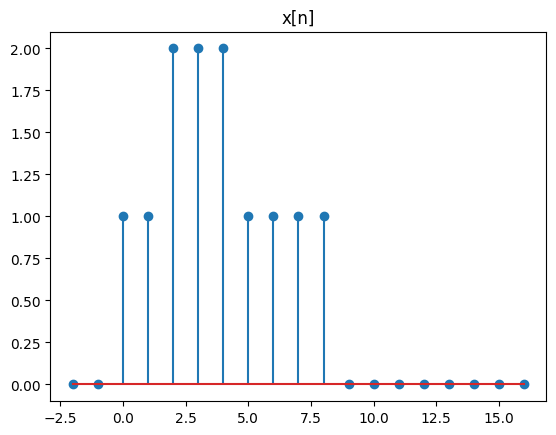

In [ ]:
# escreva o seu código aqui
def u(n):
  return np.where(n >= 0, 1, 0)

n = np.arange(-2, 17)

x1 = u(n) * u(8-n)
x2 = u(n-2) - u(n-5)
x = x1 + x2

plt.title("x[n]")
plt.stem(n, x)

# PROBLEMA 4
Considere o sinal
$$
    y[n] = \begin{cases}
        2, & n=0 \\
        1, & n=1 \\
        -1, & n=3 \\
        3, & n=4 \\
        0, & \text{caso contrário}
    \end{cases}
$$

Escreva uma função python ($y[n]$) que implemente a equação acima para que você possa responder as questões que seguem.

**DICA:** Escreva o sinal $y[n]$ usando funções impulsos.

In [ ]:
def y(n):
    """
    Use a função dimpulse do módulo sigsys para diretamente definir
    o sinal y[n]
    """
    # # insira seu código aqui

    yy = 2 * ssd.dimpulse(n - 0) + 1 * ssd.dimpulse(n - 1) + -1 * ssd.dimpulse(n - 3) + 3 * ssd.dimpulse(n-4)

    return yy

Intervalo: [-15 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2
   3   4   5   6   7   8   9  10  11  12  13  14  15]


<StemContainer object of 3 artists>

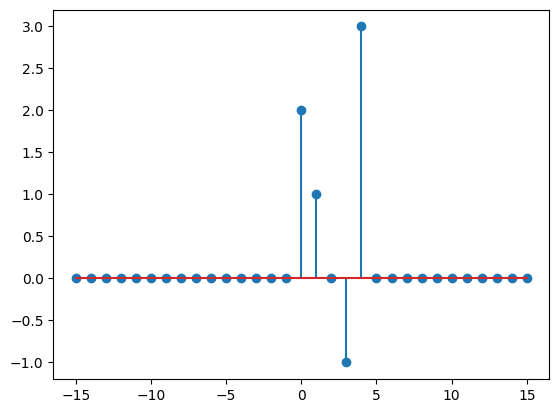

In [ ]:
n = np.arange(-15, 16)
print(f'Intervalo: {n}')

plt.stem(n, y(n))

## Parte a
Usando a função `stem()` plote $z_1[n] = y[n-2]$.

<StemContainer object of 3 artists>

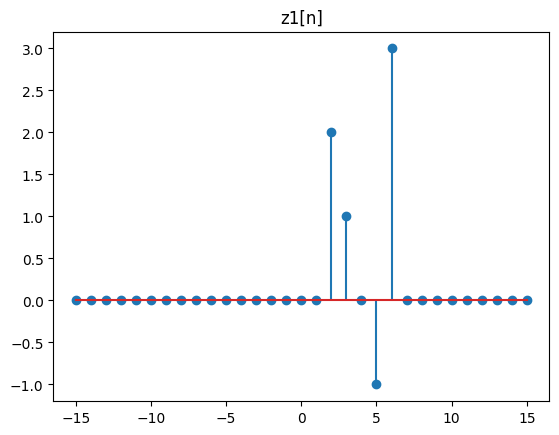

In [ ]:
# escreva o seu código aqui
plt.title("z1[n]")
plt.stem(n, y(n-2))

## Parte b
Usando a função `stem()` plote $z_2[n] = y[n+2]$.

<StemContainer object of 3 artists>

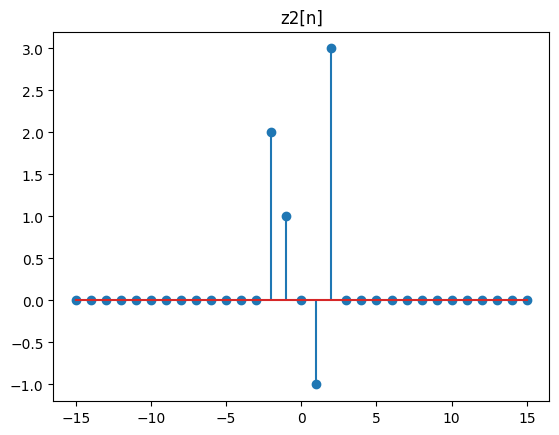

In [ ]:
# escreva o seu código aqui
plt.title("z2[n]")
plt.stem(n, y(n+2))

## Parte c
Usando a função `stem()` plote $z_3[n] = y[-n]$.

<StemContainer object of 3 artists>

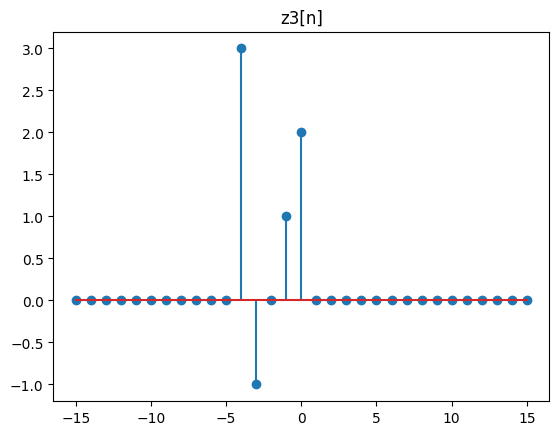

In [ ]:
# escreva o seu código aqui
plt.title("z3[n]")
plt.stem(n, y(-n))

## Parte d
Usando a função `stem()` plote $z_4[n] = 2*y[-2*n+3]$.

<StemContainer object of 3 artists>

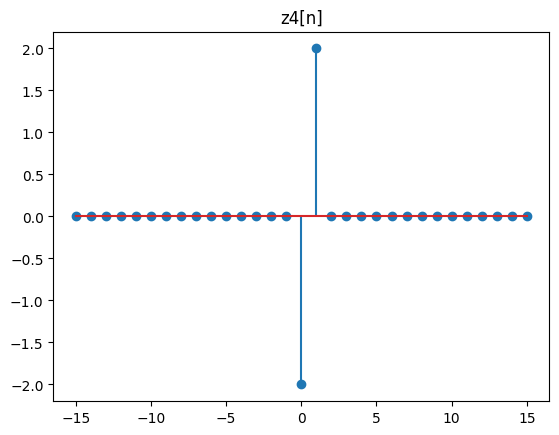

In [ ]:
# escreva o seu código aqui
plt.title("z4[n]")
plt.stem(n, 2 * y(-2 * n + 3))